In [ ]:
# import library
import pandas as pd
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# import data
data = pd.read_csv('/content/imbalanced-data-for-fine-tuning-sa-2.csv')
data.head()

,text,labels
0,pelayanan di rs triharsi untk dokter perawatny...,positive
1,alhamdulillaah pelayanan diigd sangat memuaska...,positive
2,baik,positive
3,puas denngan pelayanannya,positive
4,untuk parkir perlu di perbaiki paling tidak di...,negative


In [ ]:
# count sentiment
data['labels'].value_counts()

,count
labels,
positive,710
negative,178


In [ ]:
# load model and create pipeline for fill-mask
pipe = pipeline("fill-mask", model="indolem/indobertweet-base-uncased")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of the model checkpoint at indolem/indobertweet-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# fungsi untuk augmentasi teks
def aug(text, pipe, num_variations=3):
    augmented_texts = []
    text_with_mask = str(text) + " [MASK]."
    predictions = pipe(text_with_mask, top_k=num_variations)
    for pred in predictions:
        augmented_text = text_with_mask.replace("[MASK]", pred['token_str'])
        augmented_texts.append(augmented_text)
    return augmented_texts

In [ ]:
# augmentasi
augmented_data = []
max_augmentations = 1000
for index, row in data.iterrows():
    if row['labels'] == "negative":
        augmented_new = aug(row['text'], pipe)
        for augmented_text in augmented_new:
          if len(augmented_data) < max_augmentations:
            augmented_data.append({"text": augmented_text, "labels": "negative"})
          else:
            break
        if len(augmented_data) >= max_augmentations:
            break

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
augmented = pd.DataFrame(augmented_data)
augmented.head()

,text,labels
0,untuk parkir perlu di perbaiki paling tidak di...,negative
1,untuk parkir perlu di perbaiki paling tidak di...,negative
2,untuk parkir perlu di perbaiki paling tidak di...,negative
3,"pelayanan kurang bagus, antrian lama, ruangan ...",negative
4,"pelayanan kurang bagus, antrian lama, ruangan ...",negative


In [ ]:
augmented['labels'].value_counts()

,count
labels,
negative,534


In [ ]:
# bagi data menjadi data positif dan negatif
pos_data = data[data['labels'] == 'positive'].copy()
neg_data = data[data['labels'] == 'negative'].copy()

In [ ]:
# karena kita memperbanyak sampel negative sebanyak 360
# maka kita ambil data positive sebanyak 360
# agar tetap seimbang
sampled_pos_data = pos_data.sample(n=534, random_state=42)

In [ ]:
# gabungkan positive (sampled) dengan negative (original)
combined_sampled_data = pd.concat([sampled_pos_data, neg_data], ignore_index=True)

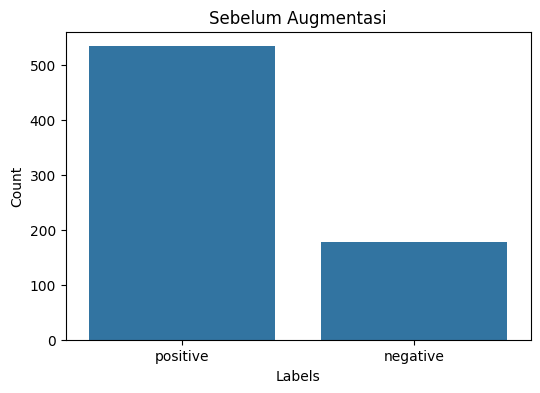

In [ ]:
# hitung label
label_counts = combined_sampled_data['labels'].value_counts()

# visualization
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Sebelum Augmentasi')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()

In [ ]:
# gabungkan sampled_pos_data dengan hasil augmentasi
combined_augmented_data = pd.concat([sampled_pos_data, augmented], ignore_index=True)

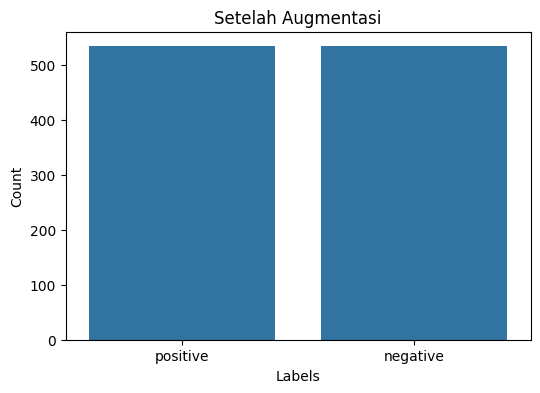

In [ ]:
# hitung label
augmented_label_counts = combined_augmented_data['labels'].value_counts()

# visualization
plt.figure(figsize=(6, 4))
sns.barplot(x=augmented_label_counts.index, y=augmented_label_counts.values)
plt.title('Setelah Augmentasi')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.show()

In [ ]:
# simpan hasil augmentasi, sebagai checkpoint
augmented.to_csv('hasil-augmentasi.csv', index = False)

In [ ]:
# simpan data hasil concat, sebagai dataset final
combined_augmented_data.to_csv('balanced-data-for-ft.csv', index = False)